# Lecture 4 - (10/02/2026)

Today's Topics:

- Feature Types
- Linear Regression
- Data Wrangling

## Feature Types

In [4]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/taxis.csv")
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


The structure of a dataset is the arrangement in rows and columns or our mental representation of the data.

What does a row of the table represent? The answer to this question is what we refer to as the granularity of the table.

- Nominal feature: represents “named” categories that do not have a natural ordering. Examples:
    - Dog breed groups: (herding, hound, non-sporting, sporting, terrier, toy)
    - Operating systems: (Windows, MacOS, Linux)
- Ordinal feature: represents ordered categories. Examples:
    - T-shirt size (small, medium, large)
    - Likert-scale response (disagree, neutral, agree)
    - Level of education (high school, college, graduate school)

These are subtypes of **categorical data** or **qualitative data**.

**Quantitative feature**: represents numeric amounts or quantities, both continuous and discrete. 

Examples:
- Height measured to the nearest cm,
- Price reported in US Dollars
- Number of siblings

Currently the focus of our class will be on quantitative features and doing analysis on those features, we will explore ways to apply analytic methods to qualitative data later in the course

## Linear Regression

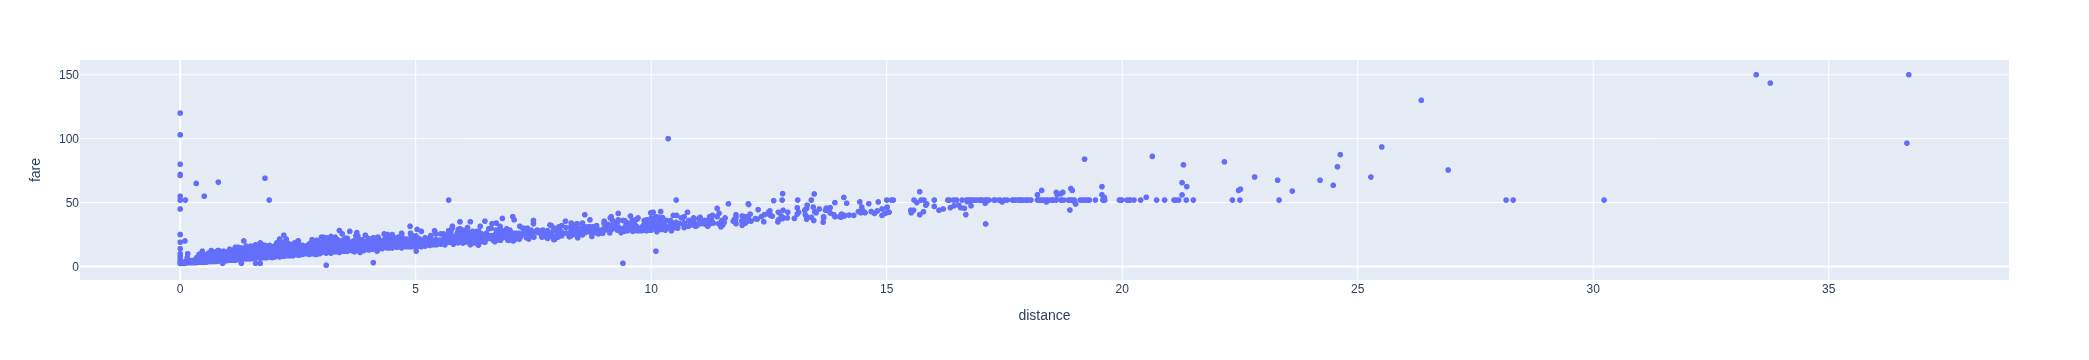

In [5]:
import plotly.express as px

px.scatter(df, x='distance', y='fare')

A regression analysis determines the relationships between a dependent variable (often called $Y$) and an independent variable(s) (often called $X$).

The results are often used for prediction, as it is the simplest example of supervised machine learning.

We will start with linear regression.

Goal: find a linear relationship between the independent and dependent variables:

$$ y = mx + b $$

Score each line with how close the actual and predicted y-values are (using RMSE for the loss function).

The best scoring line is called the regression line.

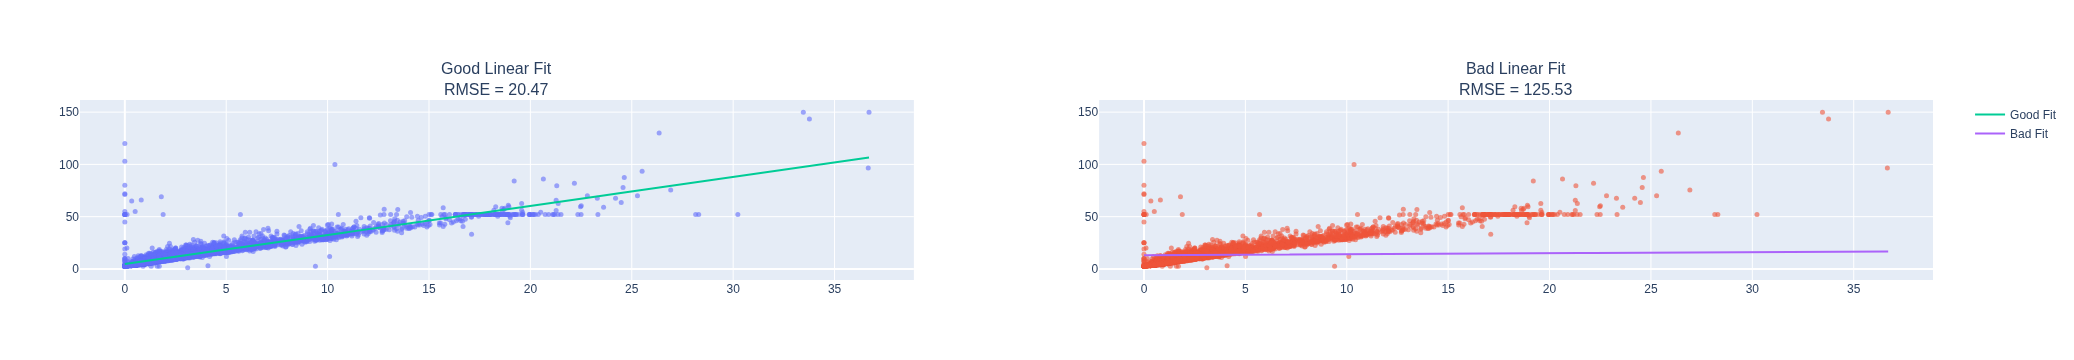

In [18]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import mean_squared_error

x = df["distance"].values
y = df["fare"].values

order = np.argsort(x)
x_sorted = x[order]
y_sorted = y[order]

# good model
coef_good = np.polyfit(x, y, 1)
y_pred_good = np.polyval(coef_good, x_sorted)
rmse_good = mean_squared_error(y, np.polyval(coef_good, x))

# bad model
coef_bad = [0.1, np.mean(y)] 
y_pred_bad = coef_bad[0] * x_sorted + coef_bad[1]
rmse_bad = mean_squared_error(y, coef_bad[0] * x + coef_bad[1])

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        f"Good Linear Fit<br>RMSE = {rmse_good:.2f}",
        f"Bad Linear Fit<br>RMSE = {rmse_bad:.2f}",
    ]
)

for col in [1, 2]:
    fig.add_trace(
        go.Scatter(
            x=x, y=y,
            mode="markers",
            marker=dict(size=5, opacity=0.6),
            showlegend=False
        ),
        row=1, col=col
    )

fig.add_trace(go.Scatter(x=x_sorted, y=y_pred_good, mode="lines", name="Good Fit"),
              row=1, col=1)

fig.add_trace(go.Scatter(x=x_sorted, y=y_pred_bad, mode="lines", name="Bad Fit"),
              row=1, col=2)

fig.show()


The correlation coefficient gives a single number measuring the association between the variables.

Regression gives a function that computes an estimate for each input.

The differences, or residuals (red lines), can give additional information.

[Residual Plot Demo Visual](https://shiney.zoology.ubc.ca/whitlock/Residuals/)

### Linear Models

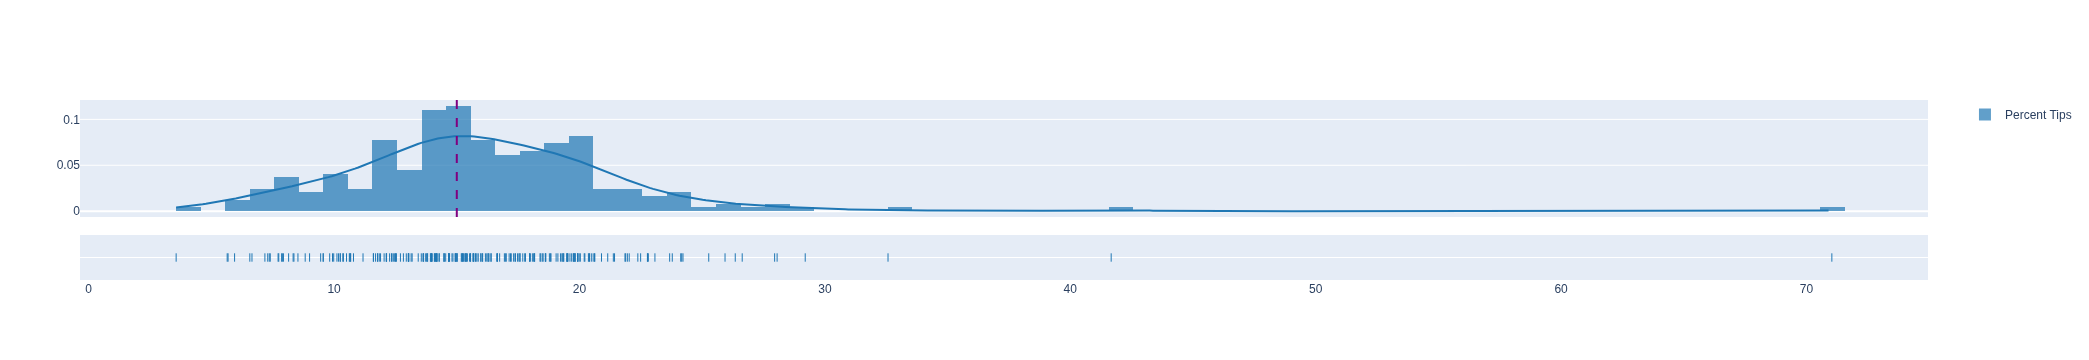

In [20]:
import plotly.figure_factory as ff

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)

tips['percent'] = tips['tip'] / tips['total_bill'] * 100
fig = ff.create_distplot([tips['percent']], ["Percent Tips"])
fig.add_vline(x=15, line_color = 'purple', line_dash = 'dash')
fig.show()

- Introduced a new variable: Percent Tip Amount.
- Asked what’s a good estimate, $\theta$, for percent tip?
- Seeking a single number, or constant model, for percent tip.

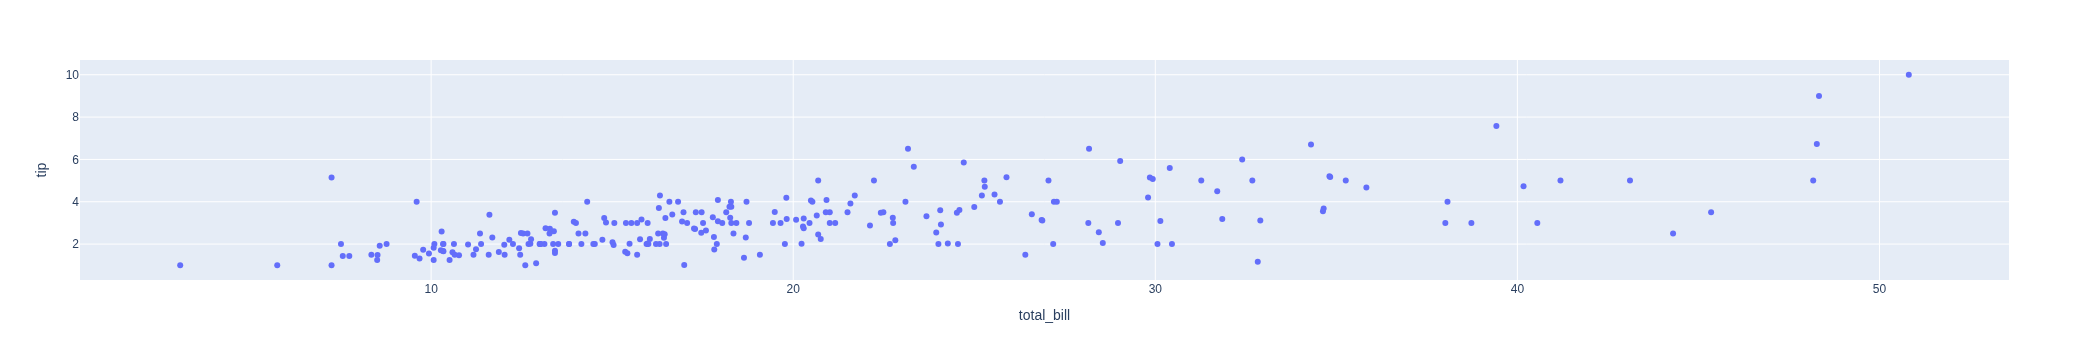

In [23]:
px.scatter(tips, x='total_bill', y='tip')

- Construct models to understand data and make predictions.
- First: focus on models which seek to explain outputs (dependent variable) via a linear function of the inputs (independent variable).
- Example: If the bill is \$20, what will the tip be?
    - Are there values for $m$ and $b$ so we can use a equation $y = mx + b$?
- $bill$ is the independent variable, and $tip$ is the dependent variable.

$$ \text{tip} = m*\text{bill} + b$$

Our model:

- m = 15\%
- b = 0

$$ \text{tip} = 0.15* \text{bill} + 0$$

But there are infinitely many linear models that we can use, how do we determine which one is best?

That's what our loss function solves.

## Data Wrangling

Recap: Aggregation functions

In [26]:
baby = pd.read_csv("https://raw.githubusercontent.com/jsvine/babynames/refs/heads/master/data/name-counts.csv")
baby.head()

,year,name,sex,count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746


We will often want to combine or aggregate data in our analysis.

Most summary statistics are available

In [32]:
baby['count'].mean()

np.float64(187.49936886275893)

In [29]:
baby['count'].std()

np.float64(1590.4001929154851)

In [31]:
baby['count'].sum()

np.int64(329760765)

### Aggregating data

How many babies are born each year?

- Can similarly group data by attributes/columns in pandas:

- `groupby()` return a Series

![image](../attachments/pandas_groupby.png)

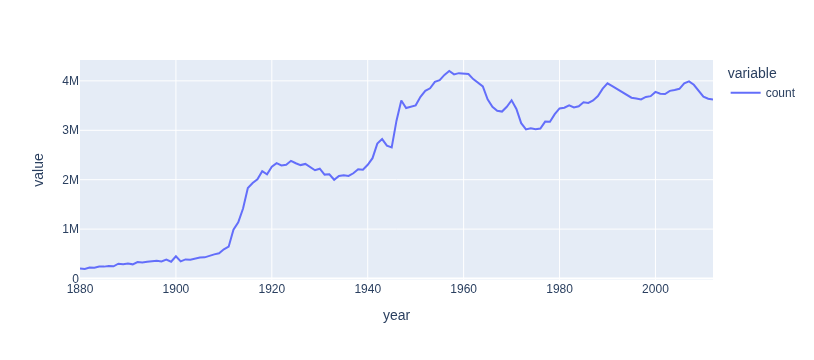

In [42]:
count_by_year = (baby     # the dataframe
    .groupby('year')      # column to group
    ['count']             # column to aggregate
    .sum()                # how to aggregate
    )
px.line(count_by_year)

In [43]:
unique_combos = (baby             # the dataframe
    .groupby(['sex', 'year'])     # make a group for each unique 'sex'+'year' 
    ['count']                     # aggregate the 'count' column
    .sum()                        # via summing the 'count' column
    .reset_index()                # use this sum as the new count
)

unique_combos

,sex,year,count
0,F,1880,90993
1,F,1881,91955
2,F,1882,107850
3,F,1883,112322
4,F,1884,129022
...,...,...,...
261,M,2008,2035075
262,M,2009,1977632
263,M,2010,1911572
264,M,2011,1889557


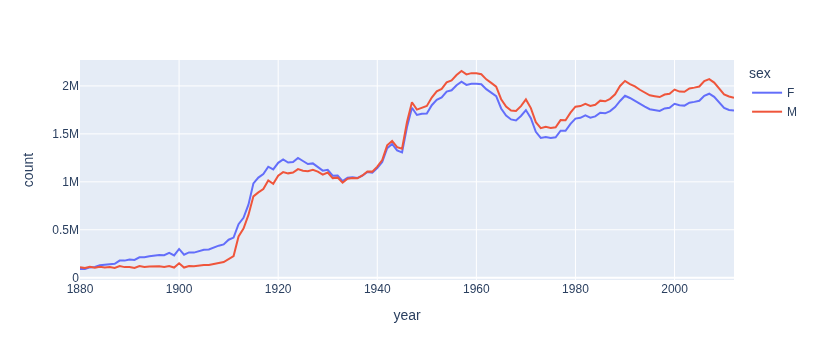

In [39]:
px.line(unique_combos, x='year', y='count', color='sex')

### Pivoting 

- When grouping by multiple columns, a useful tool is pivoting.
- Idea: use “groupby” attributes to be row and column indices:

In [44]:
mf_pivot = pd.pivot_table(
    baby,             # the dataframe
    index='year',     # column to make the new index
    columns='sex',    # column to turn into new columns
    values='count',   # column to aggregate for values
    aggfunc=sum)      # how to aggregate said column

mf_pivot

sex,F,M
year,,
1880,90993,110491
1881,91955,100746
1882,107850,113687
1883,112322,104630
1884,129022,114445
...,...,...
2008,1886109,2035075
2009,1831382,1977632
2010,1770632,1911572


### Joins in Pandas

Pandas has ways to merge or join information from different tables (similar to SQL, covered at the end of the term).

![image](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fmiro.medium.com%2Fv2%2Fresize%3Afit%3A900%2F1*yb76Gk03pZsjVDp79n2yKA.jpeg&f=1&nofb=1&ipt=57e50c471a826e89000742252a653f643680e67e9f7c24ad3b878d8a864139d6)

In [97]:
# gen 1
kanto_df = pd.DataFrame({
    "pokemon": ["Bulbasaur", "Charmander", "Squirtle", "Pikachu", "Jigglypuff"],
    "type": ["Grass", "Fire", "Water", "Electric", "Fairy"],
    "generation": [1, 1, 1, 1, 1]
})

# gen 2
johto_df = pd.DataFrame({
    "pokemon": ["Chikorita", "Cyndaquil", "Totodile", "Pikachu", "Jigglypuff"],
    "type": ["Grass", "Fire", "Water", "Electric", "Fairy"],
    "generation": [2, 2, 2, 1, 1]
})


In [98]:
kanto_df

,pokemon,type,generation
0,Bulbasaur,Grass,1
1,Charmander,Fire,1
2,Squirtle,Water,1
3,Pikachu,Electric,1
4,Jigglypuff,Fairy,1


In [99]:
johto_df

,pokemon,type,generation
0,Chikorita,Grass,2
1,Cyndaquil,Fire,2
2,Totodile,Water,2
3,Pikachu,Electric,1
4,Jigglypuff,Fairy,1


An inner join only joins the rows that have the key value in both tables:

In [100]:
pd.merge(kanto_df, johto_df, on="pokemon", how="inner")

,pokemon,type_x,generation_x,type_y,generation_y
0,Pikachu,Electric,1,Electric,1
1,Jigglypuff,Fairy,1,Fairy,1


- Mathematically can be treated as a intersection

A full outer join adds all the rows of the table on the key value, adding in nulls if a value is missing

In [101]:
pd.merge(kanto_df, johto_df, on="pokemon", how="outer")

,pokemon,type_x,generation_x,type_y,generation_y
0,Bulbasaur,Grass,1.0,NaN,NaN
1,Charmander,Fire,1.0,NaN,NaN
2,Chikorita,NaN,NaN,Grass,2.0
3,Cyndaquil,NaN,NaN,Fire,2.0
4,Jigglypuff,Fairy,1.0,Fairy,1.0
5,Pikachu,Electric,1.0,Electric,1.0
6,Squirtle,Water,1.0,NaN,NaN
7,Totodile,NaN,NaN,Water,2.0


Notice how it adds _x for left and _y for the right tables, we can specify a suffix as follows:

In [103]:
pd.merge(kanto_df, johto_df, on="pokemon", how="outer", suffixes=("_kanto", "_johto"))

,pokemon,type_kanto,generation_kanto,type_johto,generation_johto
0,Bulbasaur,Grass,1.0,NaN,NaN
1,Charmander,Fire,1.0,NaN,NaN
2,Chikorita,NaN,NaN,Grass,2.0
3,Cyndaquil,NaN,NaN,Fire,2.0
4,Jigglypuff,Fairy,1.0,Fairy,1.0
5,Pikachu,Electric,1.0,Electric,1.0
6,Squirtle,Water,1.0,NaN,NaN
7,Totodile,NaN,NaN,Water,2.0


A left join adds all the rows from the left table on the key value, filling in null for the missing values

In [104]:
pd.merge(kanto_df, johto_df, on="pokemon", how="left", suffixes=("_kanto", "_johto"))

,pokemon,type_kanto,generation_kanto,type_johto,generation_johto
0,Bulbasaur,Grass,1,NaN,NaN
1,Charmander,Fire,1,NaN,NaN
2,Squirtle,Water,1,NaN,NaN
3,Pikachu,Electric,1,Electric,1.0
4,Jigglypuff,Fairy,1,Fairy,1.0


Left-only pokemon have `NaN` for right table columns.

In [105]:
pd.merge(kanto_df, johto_df, on="pokemon", how="right", suffixes=("_kanto", "_johto"))

,pokemon,type_kanto,generation_kanto,type_johto,generation_johto
0,Chikorita,NaN,NaN,Grass,2
1,Cyndaquil,NaN,NaN,Fire,2
2,Totodile,NaN,NaN,Water,2
3,Pikachu,Electric,1.0,Electric,1
4,Jigglypuff,Fairy,1.0,Fairy,1


Right-only pokemon have `NaN` for right table columns.

### Zips and List Comprehension

zips: combines iterables into a single iterable.

In [118]:
first_name = ['Alice', 'Bob', 'Charlie']
last_name = ['Hill', 'Irvin', 'Jones']
birth_year = [2003, 2006, 2004]

my_zip = zip(first_name, last_name, birth_year)
print(f'{list(my_zip)}')

[('Alice', 'Hill', 2003), ('Bob', 'Irvin', 2006), ('Charlie', 'Jones', 2004)]


In [121]:
for first, last, year in zip(first_name, last_name, birth_year):
    print(f"{last}, {first} was born in {year}")

Hill, Alice was born in 2003
Irvin, Bob was born in 2006
Jones, Charlie was born in 2004


This is most commonly used in setting up dataframes in pandas

In [124]:
df = pd.DataFrame(list(zip(first_name, last_name, birth_year)),
                  columns = ['First Name', 'Last Name', 'Year of Birth'])

df

,First Name,Last Name,Year of Birth
0,Alice,Hill,2003
1,Bob,Irvin,2006
2,Charlie,Jones,2004


List comprehension is an effective way to traverse lists

In [125]:
nums = [0,1,2,3,4]
sq = [x*x for x in nums]
print(sq)

[0, 1, 4, 9, 16]


In [127]:
evens = [num for num in range(10) if num%2 == 0]
evens

[0, 2, 4, 6, 8]

In [128]:
even_sq = [num*num for num in range(10) if num%2 == 0]
even_sq

[0, 4, 16, 36, 64]

If you get to the point where you need a nested loop, probably best to fall back to multiple lines

In [131]:
list1 = [1, 2, 3 ]
list2 = [1, 2, 3 ]
result = [i*k for i in list1 for k in list2]

result

[1, 2, 3, 2, 4, 6, 3, 6, 9]